# Hybrid Lorentz-ParT MAE for JetClass
This notebook implements a GSoC 2026 jet classification pipeline with MAE pretraining and hybrid modeling.

## 1. Motivation
Jet tagging needs models that capture both particle interactions and Lorentz-aware structure.
We combine ParT and Lorentz-inspired blocks, then fine-tune after MAE pretraining.

## 2. Setup
Imports, seeds, paths, and runtime settings are configured here.

In [1]:
import os, math, time, json, random, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except ImportError:
    HAS_ROOT = False


In [2]:
@dataclass
class Config:
    DATA_ROOT: str = '../datasets/JetClass'
    MAX_PARTICLES: int = 50                                        
                                                                  
                                                                                             
    NUM_CLASSES: int = 10

                                                                           
                                                                      
                                                                   
                                                                    
    BATCH_SIZE: int = 128
    NUM_WORKERS: int = 0
    PRETRAIN_EPOCHS: int = 20                                                                 
    FINETUNE_EPOCHS: int = 35                                                               
    LEARNING_RATE: float = 3e-4

                                                                         
                                                                            
    WEIGHT_DECAY: float = 0.01
    MASK_RATIO: float = 0.4

                                                                              
                                                                              
                                                          
                                                                      
                                                                      
                                                    
                                                                        
    USE_PATCH_MASKING: bool = True
    PATCH_GRID_SIZE: int = 4                                         
    PATCH_ETA_RANGE: float = 0.5                        
    PATCH_PHI_RANGE: float = 0.5                        
    PATCH_MASK_FRAC: float = 0.40                               

                                                                              
                                                                        
                                                                              
    USE_MASK_TOKEN: bool = True

                                                                              
    USE_PID_PRETRAIN_HEAD: bool = True
    PID_HEAD_WEIGHT: float = 0.5                                                 

                                                                           
    WARMUP_EPOCHS: int = 3
    LABEL_SMOOTHING: float = 0.1
    USE_BIASED_MASK: bool = True

                                                                        
                                                                          
                                                                     
                                                                           
    BACKBONE_LR_FACTOR: float = 0.3

                                                                           
    KINEMATIC_LOG_FEATURES: Tuple[str, ...] = ('px', 'py', 'pz', 'E', 'pt', 'deltaR')
                                                                                           
    MASS_TARGET_NORMALIZE: bool = True
    MASS_NORM_EPS: float = 1e-6
    GATE_REG_WEIGHT: float = 0.02                                                  

                                                                            
    USE_JEPA_PRETRAIN: bool = False                                                        
                                                                                      
                                                                 
    JEPA_WEIGHT: float = 0.5
    JEPA_EMA_DECAY: float = 0.996

                                                                  
    ATTN_INTERACTION_GATE_STRENGTH: float = 1.0

                                               
    USE_PHYSICS_RECO_WEIGHTING: bool = True
    RECO_WEIGHT_PT: float = 1.0
    RECO_WEIGHT_ETA: float = 0.5
    RECO_WEIGHT_PHI: float = 0.3
    RECO_WEIGHT_E: float = 1.0
    RECO_WEIGHT_DEFAULT: float = 0.7

    USE_AUX_MASS: bool = False
    USE_CLASS_WEIGHTS: bool = True
    USE_MIXED_PRECISION: bool = True
    QUICK_DEMO_MODE: bool = False
    QUICK_MAX_EVENTS_PER_FILE: int = 1000
    FULL_MAX_EVENTS_PER_FILE: Optional[int] = 2500

                                                                        
                                                                         
                                                                         
                                                                      
                                                                             
                                                                           
                                                                              
    SAMPLE_SIZE_LIMIT: int = 100000
    ENFORCE_STRICT_100K_WHEN_AVAILABLE: bool = True
    SAMPLING_SEED: Optional[int] = 42

    NUM_TRAIN_FILES: Optional[int] = None
    NUM_VAL_FILES: Optional[int] = None
    NUM_TEST_FILES: Optional[int] = None

                                                                  
                                                                             
                                                
                                                        
                                                                         
                                                                         
                                                                        
    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
                                                 
        'px', 'py', 'pz', 'E',
                                                                      
                                                                          
                                                                            
                                                                          
                                                                           
        'pt', 'deta', 'dphi', 'deltaR',
                                                                         
        'charge',
        'isChargedHadron', 'isNeutralHadron', 'isPhoton',
        'isElectron', 'isMuon',
                                                                                 
        'd0val', 'd0err', 'dzval', 'dzerr',
        'valid_mask',
    )
    PAIRWISE_FEATURES: Tuple[str, ...] = ('lnDelta', 'lnkT', 'lnz', 'lnm2')
                                                                                     
    SCALE_FEATURES: Tuple[str, ...] = ('charge', 'd0val', 'd0err', 'dzval', 'dzerr')
                                                                   
                                                                      

                                                                                
                                                                               
    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_LAYERS_PART: int = 6              
    NUM_LAYERS_LORENTZ: int = 4           
    NUM_CLS_BLOCKS: int = 2                                                 
    MLP_RATIO: float = 4.0
    DROPOUT: float = 0.15                                                                      
    USE_TOKEN_GATE: bool = True
    USE_EVENT_GATE: bool = True

    W_RECO: float = 1.0
    W_CONS: float = 0.2
    W_CLASS: float = 1.0
    AUX_MASS_WEIGHT: float = 0.2

    GRAD_CLIP_NORM: float = 1.0
                                                                        
                                                                  
    EARLY_STOP_PATIENCE: int = 10
    SEED: int = 42

                                                                         
                                                                          
                                                                       
                                                                                
    CUDNN_BENCHMARK: bool = True

                                                                           
    SIGNAL_EFF_STANDARD: float = 0.50
    SIGNAL_EFF_HIGH:     float = 0.99

cfg = Config()
cfg

Config(DATA_ROOT='../datasets/JetClass', MAX_PARTICLES=50, NUM_CLASSES=10, BATCH_SIZE=128, NUM_WORKERS=0, PRETRAIN_EPOCHS=20, FINETUNE_EPOCHS=35, LEARNING_RATE=0.0003, WEIGHT_DECAY=0.01, MASK_RATIO=0.4, USE_PATCH_MASKING=True, PATCH_GRID_SIZE=4, PATCH_ETA_RANGE=0.5, PATCH_PHI_RANGE=0.5, PATCH_MASK_FRAC=0.4, USE_MASK_TOKEN=True, USE_PID_PRETRAIN_HEAD=True, PID_HEAD_WEIGHT=0.5, WARMUP_EPOCHS=3, LABEL_SMOOTHING=0.1, USE_BIASED_MASK=True, BACKBONE_LR_FACTOR=0.3, KINEMATIC_LOG_FEATURES=('px', 'py', 'pz', 'E', 'pt', 'deltaR'), MASS_TARGET_NORMALIZE=True, MASS_NORM_EPS=1e-06, GATE_REG_WEIGHT=0.02, USE_JEPA_PRETRAIN=False, JEPA_WEIGHT=0.5, JEPA_EMA_DECAY=0.996, ATTN_INTERACTION_GATE_STRENGTH=1.0, USE_PHYSICS_RECO_WEIGHTING=True, RECO_WEIGHT_PT=1.0, RECO_WEIGHT_ETA=0.5, RECO_WEIGHT_PHI=0.3, RECO_WEIGHT_E=1.0, RECO_WEIGHT_DEFAULT=0.7, USE_AUX_MASS=False, USE_CLASS_WEIGHTS=True, USE_MIXED_PRECISION=True, QUICK_DEMO_MODE=False, QUICK_MAX_EVENTS_PER_FILE=1000, FULL_MAX_EVENTS_PER_FILE=2500, SAMPLE_

In [3]:
def seed_everything(seed: int, benchmark: bool = True) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
                                                                               
                                                             
    torch.backends.cudnn.deterministic = not benchmark
    torch.backends.cudnn.benchmark = benchmark

seed_everything(cfg.SEED, benchmark=cfg.CUDNN_BENCHMARK)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_MIXED_PRECISION and device.type == 'cuda'
print('Device:', device)
print('Mixed precision:', amp_enabled)
print('ROOT stack available:', HAS_ROOT)


Device: cuda
Mixed precision: True
ROOT stack available: True


## 3. Data Understanding
We inspect class distribution and basic particle-level statistics before training.

In [4]:
def resolve_data_root(user_path: str) -> Path:
    raw = Path(user_path)
    candidates = [
        raw,
        Path.cwd() / raw,
        Path.cwd().parent / raw,
        Path.cwd() / 'datasets' / 'JetClass',
        Path.cwd().parent / 'datasets' / 'JetClass',
    ]

    seen = set()
    for candidate in candidates:
        rp = candidate.resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if rp.exists() and rp.is_dir():
            return rp

    tried = '\n'.join([f' - {c.resolve()}' for c in candidates])
    raise FileNotFoundError('Could not locate JetClass data root. Tried:\n' + tried)

def discover_root_files(data_root: Path) -> List[Path]:
    return sorted(data_root.rglob('*.root')) if data_root.exists() else []

def infer_class_name(path: Path) -> str:
    return path.stem.split('_')[0]

data_root = resolve_data_root(cfg.DATA_ROOT)
cfg.DATA_ROOT = str(data_root)
files = discover_root_files(data_root)
print('CWD:', Path.cwd())
print('Data root:', data_root.resolve())
print('ROOT files found:', len(files))
for p in files[:8]:
    print(' -', p.name)

classes = sorted({infer_class_name(p) for p in files}) if files else []
print('Inferred classes:', classes)


CWD: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\notebook
Data root: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\datasets\JetClass
ROOT files found: 100
 - HToBB_000.root
 - HToBB_001.root
 - HToBB_002.root
 - HToBB_003.root
 - HToBB_004.root
 - HToBB_005.root
 - HToBB_006.root
 - HToBB_007.root
Inferred classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']


In [5]:
BRANCH_CANDIDATES = {
    'px':    ['part_px', 'px', 'PFCands_px', 'particle_px'],
    'py':    ['part_py', 'py', 'PFCands_py', 'particle_py'],
    'pz':    ['part_pz', 'pz', 'PFCands_pz', 'particle_pz'],
    'E':     ['part_energy', 'part_e', 'energy', 'E', 'PFCands_energy', 'particle_e'],
                                                                                  
                                                                                    
                                                                                      
    'pt':    ['part_pt', 'pt', 'PFCands_pt', 'particle_pt'],
    'deta':  ['part_deta', 'deta', 'part_eta'],                             
    'dphi':  ['part_dphi', 'dphi', 'part_phi'],                             
    'eta':   ['part_eta', 'eta', 'PFCands_eta', 'particle_eta'],                                    
    'phi':   ['part_phi', 'phi', 'PFCands_phi', 'particle_phi'],                                    
    'charge':['part_charge', 'charge', 'PFCands_charge', 'particle_charge'],
                                                                               
    'isChargedHadron': ['part_isChargedHadron', 'isChargedHadron', 'PFCands_isChargedHadron'],
    'isNeutralHadron': ['part_isNeutralHadron', 'isNeutralHadron', 'PFCands_isNeutralHadron'],
    'isPhoton':        ['part_isPhoton',        'isPhoton',        'PFCands_isPhoton'],
    'isElectron':      ['part_isElectron',      'isElectron',      'PFCands_isElectron'],
    'isMuon':          ['part_isMuon',          'isMuon',          'PFCands_isMuon'],
                                                                              
    'd0val':  ['part_d0val',  'd0val',  'PFCands_d0val'],
    'd0err':  ['part_d0err',  'd0err',  'PFCands_d0err'],
    'dzval':  ['part_dzval',  'dzval',  'PFCands_dzval'],
    'dzerr':  ['part_dzerr',  'dzerr',  'PFCands_dzerr'],
}

def resolve_branches(available: List[str], candidates: Dict[str, List[str]]) -> Dict[str, Optional[str]]:
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        hit = None
        for o in opts:
            if o in available:
                hit = o
                break
            if o.lower() in lower:
                hit = lower[o.lower()]
                break
        out[k] = hit
    return out

if HAS_ROOT and files:
    with uproot.open(files[0]) as f:
        tree_name = None
        for c in ['tree', 'events', 'Events', 'JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'keys'):
                    tree_name = k
                    break
        print('Selected tree:', tree_name)
        branches = [str(b) for b in f[tree_name].keys()]
        print('First branches:', branches[:30])
        resolved = resolve_branches(branches, BRANCH_CANDIDATES)
        print('Resolved map:', resolved)
        print('\nParticle-ID branches found:',
              {k: v for k, v in resolved.items()
               if k in ('isChargedHadron','isNeutralHadron','isPhoton','isElectron','isMuon')})
        print('Displacement branches found:',
              {k: v for k, v in resolved.items()
               if k in ('d0val','d0err','dzval','dzerr')})
else:
    print('No ROOT file available for branch inspection.')


Selected tree: tree
First branches: ['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy']
Resolved map: {'px': 'part_px', 'py': 'part_py', 'pz': 'part_pz', 'E': 'part_energy', 'pt': None, 'deta': 'part_deta', 'dphi': 'part_dphi', 'eta': None, 'phi': None, 'charge': 'part_charge', 'isChargedHadron': 'part_isChargedHadron', 'isNeutralHadron': 'part_isNeutralHadron', 'isPhoton': 'part_isPhoton', 'isElectron': 'part_isElectron', 'isMuon': 'part_isMuon', 'd0val': 'part_d0val', 'd0err': 'part_d0err', 'dzval': 'part_dzval', 'dzerr': 'part_dzerr'}

Particle-ID branches found: {'isChargedHadron': 'part_isChargedHadron', 'isNeutralHa

## 4. ROOT Data Loading
JetClass ROOT files are loaded and transformed into model-ready arrays.

In [6]:
def safe_eta(px: np.ndarray, py: np.ndarray, pz: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    ratio = np.clip(pz / np.maximum(p, eps), -1.0 + 1e-6, 1.0 - 1e-6)
    return np.arctanh(ratio).astype(np.float32)

def _safe_event_arrays(arr_list: List[Any], dtype=np.float32) -> List[np.ndarray]:
    out = []
    for arr in arr_list:
        a = np.asarray(arr, dtype=dtype)
        out.append(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0))
    return out

def read_jetclass_root(file_path: Path, max_events: Optional[int]) -> List[Dict[str, np.ndarray]]:
    if not HAS_ROOT:
        raise RuntimeError('uproot/awkward not installed.')

    events = []
    with uproot.open(file_path) as f:
        tree_name = None
        for c in ['tree', 'events', 'Events', 'JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'arrays'):
                    tree_name = k
                    break
        tree = f[tree_name]
        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)

        has_cartesian = bm['px'] is not None and bm['py'] is not None and bm['pz'] is not None
        has_cyl = bm['pt'] is not None and bm['eta'] is not None and bm['phi'] is not None
        if not (has_cartesian or has_cyl):
            raise ValueError(f'Missing momentum branches in {file_path.name}')

        read_keys = list({v for v in bm.values() if v is not None})
        arrs = tree.arrays(read_keys, library='ak', entry_stop=max_events)

                                                                            
        if has_cartesian:
            pxL = _safe_event_arrays(ak.to_list(arrs[bm['px']]))
            pyL = _safe_event_arrays(ak.to_list(arrs[bm['py']]))
            pzL = _safe_event_arrays(ak.to_list(arrs[bm['pz']]))
            ptL  = [np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32) for px, py in zip(pxL, pyL)]
            etaL = [safe_eta(px, py, pz).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]
            phiL = [np.arctan2(py, px).astype(np.float32) for py, px in zip(pyL, pxL)]
        else:
            ptL  = _safe_event_arrays(ak.to_list(arrs[bm['pt']]))
            etaL = _safe_event_arrays(ak.to_list(arrs[bm['eta']]))
            phiL = _safe_event_arrays(ak.to_list(arrs[bm['phi']]))
            pxL  = [(pt * np.cos(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pyL  = [(pt * np.sin(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pzL  = [(pt * np.sinh(eta)).astype(np.float32) for pt, eta in zip(ptL, etaL)]

        EL = (_safe_event_arrays(ak.to_list(arrs[bm['E']])) if bm['E'] is not None
              else [np.sqrt(px**2 + py**2 + pz**2 + 1e-8).astype(np.float32)
                    for px, py, pz in zip(pxL, pyL, pzL)])

        qL = (_safe_event_arrays(ak.to_list(arrs[bm['charge']])) if bm['charge'] is not None
              else [np.zeros_like(px, dtype=np.float32) for px in pxL])

                                                                            
        def _read_optional(key: str, ref_list):
            if bm.get(key) is not None:
                return _safe_event_arrays(ak.to_list(arrs[bm[key]]))
            return [np.zeros_like(r, dtype=np.float32) for r in ref_list]

        isCHL  = _read_optional('isChargedHadron', pxL)
        isNHL  = _read_optional('isNeutralHadron', pxL)
        isPhL  = _read_optional('isPhoton',        pxL)
        isElL  = _read_optional('isElectron',      pxL)
        isMuL  = _read_optional('isMuon',          pxL)

                                                                            
        d0vL   = _read_optional('d0val', pxL)
        d0eL   = _read_optional('d0err', pxL)
        dzvL   = _read_optional('dzval', pxL)
        dzeL   = _read_optional('dzerr', pxL)

                                                                 
                                                                                
                                                                      
        detaL  = _read_optional('deta', pxL)                              
        dphiL  = _read_optional('dphi', pxL)                              
                                                                              
        for i in range(len(detaL)):
            if np.allclose(detaL[i], 0.0):
                detaL[i] = etaL[i] - etaL[i].mean()                      
            if np.allclose(dphiL[i], 0.0):
                dphiL[i] = phiL[i] - phiL[i].mean()

        for (px, py, pz, E, pt, eta, phi, q,
             isCH, isNH, isPh, isEl, isMu,
             d0v, d0e, dzv, dze, deta, dphi) in zip(
                pxL, pyL, pzL, EL, ptL, etaL, phiL, qL,
                isCHL, isNHL, isPhL, isElL, isMuL,
                d0vL, d0eL, dzvL, dzeL, detaL, dphiL):

            n = min(len(px), len(py), len(pz), len(E))
            if n == 0:
                continue
                                                                                   
            deltaR = np.sqrt(deta[:n]**2 + dphi[:n]**2 + 1e-8).astype(np.float32)
            events.append({
                'px': px[:n], 'py': py[:n], 'pz': pz[:n], 'E': E[:n],
                'pt': pt[:n],
                'deta':   deta[:n],                                      
                'dphi':   dphi[:n],                                      
                'deltaR': deltaR,                                            
                'charge': q[:n],
                'isChargedHadron': isCH[:n],
                'isNeutralHadron': isNH[:n],
                'isPhoton':        isPh[:n],
                'isElectron':      isEl[:n],
                'isMuon':          isMu[:n],
                'd0val': d0v[:n],
                'd0err': d0e[:n],
                'dzval': dzv[:n],
                'dzerr': dze[:n],
                'valid_mask': np.ones(n, dtype=np.float32),
            })
    return events

def pad_event(ev: Dict[str, np.ndarray], max_particles: int, feat_order: Tuple[str, ...]):
    x    = np.zeros((max_particles, len(feat_order)), dtype=np.float32)
    mask = np.zeros((max_particles,), dtype=np.float32)
    p4   = np.zeros((max_particles, 4), dtype=np.float32)

    n = min(len(ev['px']), max_particles)
    mask[:n] = 1.0

    for j, name in enumerate(feat_order):
        arr = np.nan_to_num(
            ev.get(name, np.zeros(n, dtype=np.float32)),
            nan=0.0, posinf=0.0, neginf=0.0)
        x[:n, j] = arr[:n]

    p4[:n, 0] = np.nan_to_num(ev['E'][:n],  nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 1] = np.nan_to_num(ev['px'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 2] = np.nan_to_num(ev['py'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 3] = np.nan_to_num(ev['pz'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    return x, mask, p4

def event_mass(p4: np.ndarray, mask: np.ndarray) -> float:
    vv = p4[mask > 0.5]
    if vv.size == 0:
        return 0.0
    s = vv.sum(axis=0)
    m2 = s[0]**2 - (s[1]**2 + s[2]**2 + s[3]**2)
    return float(np.sqrt(max(m2, 0.0)))


In [7]:
class JetClassDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, mask, p4, y, mass = self.samples[idx]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(mass, dtype=torch.float32),
        }

def fit_scaler(samples, feature_names: Tuple[str, ...], scale_features: Tuple[str, ...]):
    scale_idx = [feature_names.index(f) for f in scale_features if f in feature_names]
    if len(scale_idx) == 0:
        return None, []

    scaler = StandardScaler()
    buf = []
    for x, mask, *_ in samples:
        v = x[mask > 0.5]
        if len(v):
            buf.append(v[:, scale_idx])
    if buf:
        scaler.fit(np.concatenate(buf, axis=0))
    else:
        scaler.fit(np.zeros((1, len(scale_idx)), dtype=np.float32))
    return scaler, scale_idx

def apply_scaler(samples, scaler, scale_idx: List[int]):
    if scaler is None or len(scale_idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, scale_idx] = scaler.transform(xv[:, scale_idx])
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def apply_signed_log_kinematics(samples, feature_names: Tuple[str, ...], features_to_log: Tuple[str, ...]):
    idx = [feature_names.index(f) for f in features_to_log if f in feature_names]
    if len(idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, idx] = np.sign(xv[:, idx]) * np.log1p(np.abs(xv[:, idx]))
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def normalize_mass_targets(train_samples, val_samples, test_samples, eps: float = 1e-6):
    train_m = np.array([s[4] for s in train_samples], dtype=np.float32)
    mean = float(train_m.mean()) if len(train_m) else 0.0
    std = float(train_m.std()) if len(train_m) else 1.0
    std = max(std, eps)

    def _norm(samples):
        out = []
        for x, mask, p4, y, m in samples:
            out.append((x, mask, p4, y, (float(m) - mean) / std))
        return out

    return _norm(train_samples), _norm(val_samples), _norm(test_samples), mean, std

In [8]:
def random_sample_events(samples: List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]], sample_size: int, seed: Optional[int]):
    n_total = len(samples)
    if n_total <= sample_size:
        return samples

    rng = np.random.default_rng(seed)
    sampled_indices = rng.choice(n_total, size=sample_size, replace=False)
    return [samples[i] for i in sampled_indices]


def build_loaders(cfg: Config):
    files = discover_root_files(Path(cfg.DATA_ROOT))

    if files:
        cls = sorted({infer_class_name(f) for f in files})
        cfg.NUM_CLASSES = len(cls)
        c2i = {c: i for i, c in enumerate(cls)}

        labels = [infer_class_name(f) for f in files]
        tr, tmp, _, ytmp = train_test_split(files, labels, test_size=0.2, random_state=cfg.SEED, stratify=labels)
        va, te = train_test_split(tmp, test_size=0.5, random_state=cfg.SEED, stratify=ytmp)
        if cfg.NUM_TRAIN_FILES is not None:
            tr = tr[:cfg.NUM_TRAIN_FILES]
        if cfg.NUM_VAL_FILES is not None:
            va = va[:cfg.NUM_VAL_FILES]
        if cfg.NUM_TEST_FILES is not None:
            te = te[:cfg.NUM_TEST_FILES]

        selected_files = list(tr) + list(va) + list(te)

        target_n = cfg.SAMPLE_SIZE_LIMIT
        strict_mode = cfg.ENFORCE_STRICT_100K_WHEN_AVAILABLE
        rng = np.random.default_rng(cfg.SAMPLING_SEED)

        reservoir_samples = []
        seen_events = 0

        if cfg.QUICK_DEMO_MODE:
            max_events = cfg.QUICK_MAX_EVENTS_PER_FILE
        else:
            max_events = cfg.FULL_MAX_EVENTS_PER_FILE

        if max_events is None:
            retry_steps = [20000, 10000, 5000, 2000, 1000]
        else:
            retry_steps = [max(500, max_events // 2), 2000, 1000, 500]
            retry_steps = [min(max_events, s) for s in retry_steps]
            retry_steps = [s for i, s in enumerate(retry_steps) if s > 0 and s not in retry_steps[:i]]

        for file_idx, fp in enumerate(tqdm(selected_files, desc='Reading ROOT'), start=1):
            y = c2i[infer_class_name(fp)]
            try:
                events = read_jetclass_root(fp, max_events)
            except Exception as e:
                err_msg = f"{type(e).__name__}: {e}"
                is_memory_related = isinstance(e, MemoryError) or ('MemoryError' in err_msg)
                if not is_memory_related:
                    print(f"[WARN] skip {fp.name} {err_msg}")
                    continue

                events = None
                for retry_n in retry_steps:
                    print(f"[WARN] memory read issue on {fp.name}; retrying with entry_stop={retry_n}. Error: {err_msg}")
                    try:
                        events = read_jetclass_root(fp, retry_n)
                        print(f"[INFO] recovered {fp.name} with entry_stop={retry_n}")
                        break
                    except Exception as e2:
                        err_msg2 = f"{type(e2).__name__}: {e2}"
                        if not (isinstance(e2, MemoryError) or ('MemoryError' in err_msg2)):
                            print(f"[WARN] skip {fp.name} during retry: {err_msg2}")
                            events = None
                            break
                        err_msg = err_msg2

                if events is None:
                    print(f"[WARN] skip {fp.name} after memory retries")
                    continue

            for ev in events:
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                sample = (x, m, p4, y, event_mass(p4, m))
                seen_events += 1

                if len(reservoir_samples) < target_n:
                    reservoir_samples.append(sample)
                else:
                    j = int(rng.integers(0, seen_events))
                    if j < target_n:
                        reservoir_samples[j] = sample

            if file_idx % 10 == 0:
                print(f"[INFO] progress files={file_idx}/{len(selected_files)} seen_events={seen_events} kept_samples={len(reservoir_samples)}")

        if len(reservoir_samples) == 0:
            raise RuntimeError('No valid events were loaded from ROOT files.')

        if strict_mode and seen_events < target_n:
            raise RuntimeError(
                f'Strict 100k mode enabled but only {seen_events} events available. '
                f'Increase source files / disable QUICK_DEMO_MODE / relax strict mode.'
            )

        sample_n = target_n if strict_mode else min(target_n, seen_events)

                                                                            
                                                                         
                                                                             
                                                                           
                                                                           
                                                          
                                                                            
                                                                               
                                                            
        rng.shuffle(reservoir_samples)
        sampled_samples = reservoir_samples[:sample_n]

        if len(sampled_samples) != sample_n:
            raise RuntimeError(f'Sampling mismatch: expected {sample_n}, got {len(sampled_samples)}')

        sampled_labels = np.array([s[3] for s in sampled_samples])

                                                                              
                                                                              
                                                                                   
        assert len(set(id(s) for s in sampled_samples)) == len(sampled_samples),             'Duplicate samples detected — reservoir sampling failed'

                                                                                  
                                                                                               
                                                                                  
        sample_indices = np.arange(len(sampled_samples))

        tr_idx, tmp_idx = train_test_split(
            sample_indices,
            test_size=0.2,
            random_state=cfg.SEED,
            stratify=sampled_labels,
        )
        va_idx, te_idx = train_test_split(
            tmp_idx,
            test_size=0.5,
            random_state=cfg.SEED,
            stratify=sampled_labels[tmp_idx],
        )

        trS = [sampled_samples[i] for i in tr_idx]
        vaS = [sampled_samples[i] for i in va_idx]
        teS = [sampled_samples[i] for i in te_idx]

        total_split = len(trS) + len(vaS) + len(teS)
        print(f"[INFO] Total loaded events: {seen_events}")
        print(f"[INFO] Sampled events: {len(sampled_samples)} (target={target_n})")
        print(f"[INFO] Split counts train/val/test = {len(trS)}/{len(vaS)}/{len(teS)}")
        print(f"[INFO] Split ratios train/val/test = {len(trS)/total_split:.3f}/{len(vaS)/total_split:.3f}/{len(teS)/total_split:.3f}")

                                                                      
        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    else:
        print('[INFO] ROOT files not found; using synthetic fallback demo data.')
        cls = [f'Class{i}' for i in range(cfg.NUM_CLASSES)]

        def synth(n_events):
            out = []
            for _ in range(n_events):
                n = np.random.randint(8, cfg.MAX_PARTICLES)
                px = np.random.normal(0, 40, n).astype(np.float32)
                py = np.random.normal(0, 40, n).astype(np.float32)
                pz = np.random.normal(0, 60, n).astype(np.float32)
                E = np.sqrt(px**2 + py**2 + pz**2 + np.random.uniform(0, 4, n)**2).astype(np.float32)
                ev = {
                    'px': px, 'py': py, 'pz': pz, 'E': E,
                    'pt': np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32),
                                                                                                                
                    'deta': (safe_eta(px, py, pz) - safe_eta(px, py, pz).mean()).astype(np.float32),
                    'dphi': (np.arctan2(py, px) - np.arctan2(py, px).mean()).astype(np.float32),
                    'deltaR': np.sqrt((safe_eta(px, py, pz) - safe_eta(px, py, pz).mean())**2 +
                                      (np.arctan2(py, px) - np.arctan2(py, px).mean())**2 + 1e-8).astype(np.float32),
                    'charge': np.random.choice([-1, 0, 1], size=n).astype(np.float32),
                    'valid_mask': np.ones(n, dtype=np.float32),
                }
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                y = np.random.randint(0, cfg.NUM_CLASSES)
                out.append((x, m, p4, y, event_mass(p4, m)))
            return out

        trS, vaS, teS = synth(3000), synth(600), synth(600)

        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    if cfg.MASS_TARGET_NORMALIZE:
        trS, vaS, teS, mass_mean, mass_std = normalize_mass_targets(
            trS, vaS, teS, eps=cfg.MASS_NORM_EPS
        )
        cfg.MASS_MEAN = float(mass_mean)
        cfg.MASS_STD = float(mass_std)
        print(f"[INFO] Mass target normalization: mean={cfg.MASS_MEAN:.4f}, std={cfg.MASS_STD:.4f}")
    else:
        cfg.MASS_MEAN = 0.0
        cfg.MASS_STD = 1.0

    tr_labels = np.array([s[3] for s in trS], dtype=np.int64)
    cls_counts = np.bincount(tr_labels, minlength=len(cls)).astype(np.float32)
    class_weights = np.ones(len(cls), dtype=np.float32)
    nz = cls_counts > 0
    if np.any(nz):
        class_weights[nz] = cls_counts.sum() / (len(cls) * cls_counts[nz])
    class_weights = class_weights / class_weights.mean()

    trL = DataLoader(JetClassDataset(trS), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    vaL = DataLoader(JetClassDataset(vaS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    teL = DataLoader(JetClassDataset(teS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    return trL, vaL, teL, {
        'classes': cls,
        'class_weights': class_weights,
        'mass_mean': cfg.MASS_MEAN,
        'mass_std': cfg.MASS_STD,
    }

## 5. Feature Engineering
We create particle and pairwise features with numerical safeguards for stable training.

In [9]:
def normalize_angle_difference(dphi: torch.Tensor) -> torch.Tensor:
    return (dphi + math.pi) % (2 * math.pi) - math.pi

def compute_pairwise_features_from_p4(p4: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / torch.sqrt(px**2 + py**2 + pz**2 + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)
    d_phi = normalize_angle_difference(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(d_eta**2 + d_phi**2 + eps)
    lnDelta = torch.log(delta + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    lnkT = torch.log(kT + eps)

    z = torch.minimum(pti, ptj) / (pti + ptj + eps)
    lnz = torch.log(z + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    pxi, pxj = px.unsqueeze(2), px.unsqueeze(1)
    pyi, pyj = py.unsqueeze(2), py.unsqueeze(1)
    pzi, pzj = pz.unsqueeze(2), pz.unsqueeze(1)
    m2 = (Ei+Ej)**2 - ((pxi+pxj)**2 + (pyi+pyj)**2 + (pzi+pzj)**2)
    lnm2 = torch.log(torch.clamp(m2.abs(), min=eps))

    pair = torch.stack([lnDelta, lnkT, lnz, lnm2], dim=-1)             
    valid = (mask.unsqueeze(2) * mask.unsqueeze(1)).unsqueeze(-1)             
                                                                              
                                                                                      
    return torch.nan_to_num(pair * valid, nan=0.0, posinf=0.0, neginf=0.0).contiguous()

## 6. MAE Pretraining Pipeline
This section prepares masked inputs and dataloaders for self-supervised learning.

In [10]:
def make_random_mask(valid_mask: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=valid_mask.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        perm = torch.randperm(len(idx), device=valid_mask.device)
        m[b, idx[perm[:k]]] = True
    return m

def make_biased_mask_highpt(x: torch.Tensor, valid_mask: torch.Tensor,
                            mask_ratio: float, top_frac: float = 0.5) -> torch.Tensor:
    pt_idx = 4                                          
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        pt_vals = x[b, idx, pt_idx]
                                                                                
        n_high = max(1, int(len(idx) * top_frac))
        order = torch.argsort(pt_vals, descending=True)
        weights = torch.ones(len(idx), device=x.device)
        weights[order[:n_high]] = 3.0
        weights = weights / weights.sum()
        chosen = torch.multinomial(weights, k, replacement=False)
        m[b, idx[chosen]] = True
    return m

def build_mae_targets(x: torch.Tensor, p4: torch.Tensor,
                      valid_mask: torch.Tensor, mask_ratio: float,
                      biased: bool = False):
    if biased:
        reco_mask = make_biased_mask_highpt(x, valid_mask, mask_ratio)
    else:
        reco_mask = make_random_mask(valid_mask, mask_ratio)

    visible_x = x.clone()
    visible_x[reco_mask] = 0.0
    reco_target = x.clone()

    masked_p4 = p4.clone()
    masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


def make_patch_mask(x: torch.Tensor, valid_mask: torch.Tensor,
                    deta_idx: int, dphi_idx: int,
                    grid_size: int, eta_range: float, phi_range: float,
                    mask_frac: float) -> torch.Tensor:
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    n_cells = grid_size * grid_size
    n_mask  = max(1, int(n_cells * mask_frac))

    for b in range(B):
        valid_idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(valid_idx) == 0:
            continue

                                                   
        deta = x[b, valid_idx, deta_idx]
        dphi = x[b, valid_idx, dphi_idx]

                                                    
        cell_row = ((deta + eta_range) / (2 * eta_range) * grid_size).long()
        cell_col = ((dphi + phi_range) / (2 * phi_range) * grid_size).long()
        cell_row = cell_row.clamp(0, grid_size - 1)
        cell_col = cell_col.clamp(0, grid_size - 1)
        cell_id  = cell_row * grid_size + cell_col               

                                             
        perm = torch.randperm(n_cells, device=x.device)
        masked_cells = set(perm[:n_mask].tolist())

                                           
        for local_i, cid in enumerate(cell_id.tolist()):
            if cid in masked_cells:
                m[b, valid_idx[local_i]] = True

                                                                                 
                                                                        
    for b in range(B):
        if not m[b].any():
            valid_idx = torch.where(valid_mask[b] > 0.5)[0]
            if len(valid_idx) > 0:
                k = max(1, int(len(valid_idx) * mask_frac))
                perm = torch.randperm(len(valid_idx), device=x.device)
                m[b, valid_idx[perm[:k]]] = True
    return m


def apply_mask_token(x: torch.Tensor, reco_mask: torch.Tensor,
                     mask_token: torch.Tensor) -> torch.Tensor:
    out = x.clone()
    out[reco_mask] = mask_token.to(x.dtype)
    return out


def build_mae_targets(x: torch.Tensor, p4: torch.Tensor,
                      valid_mask: torch.Tensor, mask_ratio: float,
                      biased: bool = False, cfg=None):
    use_patch  = cfg is not None and getattr(cfg, 'USE_PATCH_MASKING', False)
    use_mtoken = cfg is not None and getattr(cfg, 'USE_MASK_TOKEN', False)

    if use_patch:
                                                    
        reco_mask = make_patch_mask(
            x, valid_mask,
            deta_idx   = 5,                                             
            dphi_idx   = 6,                    
            grid_size  = getattr(cfg, 'PATCH_GRID_SIZE', 4),
            eta_range  = getattr(cfg, 'PATCH_ETA_RANGE', 0.5),
            phi_range  = getattr(cfg, 'PATCH_PHI_RANGE', 0.5),
            mask_frac  = getattr(cfg, 'PATCH_MASK_FRAC', 0.40),
        )
    elif biased:
        reco_mask = make_biased_mask_highpt(x, valid_mask, mask_ratio)
    else:
        reco_mask = make_random_mask(valid_mask, mask_ratio)

    reco_target = x.clone()

                                                       
                                                                         
                                                           
                                                                             
    visible_x = x.clone()
    visible_x[reco_mask] = 0.0

    masked_p4  = p4.clone()
    masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


## 7. Model Design
The hybrid ParT + Lorentz architecture and classifier heads are defined below.

In [11]:
class ParticleFeatureEmbed(nn.Module):
    def __init__(self, in_dim: int, d: int, drop: float):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)

class PairwiseFeatureEncoder(nn.Module):
    def __init__(self, in_dim: int, heads: int):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 32), nn.GELU(), nn.Linear(32, heads))
    def forward(self, pair):
        return self.proj(pair).permute(0,3,1,2).contiguous()


In [12]:
class ParTAttentionBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1,
                 gate_strength: float = 1.0):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)
        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

                                                                                  
        self.gate_strength = gate_strength
        self.interaction_gate_bias = nn.Parameter(torch.zeros(1, heads, 1, 1))

    def forward(self, x, mask, pair_bias):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)

        attn = (q @ k.transpose(-2,-1)) * self.scale
        if pair_bias is not None:
            gate = torch.sigmoid(self.gate_strength * pair_bias + self.interaction_gate_bias)
            attn = attn + gate * pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B, N, D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [13]:
class LightweightLorentzBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)

        self.inv_proj = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))

        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - (a[...,1]*b[...,1] + a[...,2]*b[...,2] + a[...,3]*b[...,3])

    def lorentz_bias(self, p4, mask, eps: float = 1e-8):
        pi, pj = p4.unsqueeze(2), p4.unsqueeze(1)
        md = self.mdot(pi, pj)
        mi2 = self.mdot(pi, pi)
        mj2 = self.mdot(pj, pj)
        sij = self.mdot(pi+pj, pi+pj)

        feats = torch.stack([
            torch.log(torch.clamp(md.abs(), min=eps)),
            torch.log(torch.clamp(0.5*(mi2.abs()+mj2.abs()), min=eps)),
            torch.log(torch.clamp(sij.abs(), min=eps)),
        ], dim=-1)
        bias = self.inv_proj(feats).permute(0,3,1,2).contiguous()
        valid = (mask.unsqueeze(2)*mask.unsqueeze(1)).unsqueeze(1)
        return bias * valid

    def forward(self, x, p4, mask, precomputed_bias=None):
        B, N, D = x.shape
        lbias = precomputed_bias if precomputed_bias is not None else self.lorentz_bias(p4, mask)
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale + lbias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B,N,D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [14]:
class HybridGatedFusion(nn.Module):
    def __init__(self, d: int, token_gate: bool = True, event_gate: bool = True):
        super().__init__()
        self.token_gate = token_gate
        self.event_gate = event_gate
        if token_gate:
            self.gtok = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        if event_gate:
            self.gevt = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1), nn.Sigmoid())

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def forward(self, xp, xl, mask):
        c = torch.cat([xp, xl], dim=-1)
        gtok = self.gtok(c) if self.token_gate else torch.full_like(xp, 0.5)
        fused = gtok * xp + (1-gtok) * xl

        if self.event_gate:
            ep = self.masked_mean(xp, mask)
            el = self.masked_mean(xl, mask)
            ge = self.gevt(torch.cat([ep, el], dim=-1))
            fused = ge.unsqueeze(-1)*fused + (1-ge.unsqueeze(-1))*0.5*(xp+xl)
        else:
            ge = torch.full((xp.shape[0],1), 0.5, device=xp.device)

        return fused * mask.unsqueeze(-1), gtok, ge


In [15]:
class MaskedDecoderHead(nn.Module):
    def __init__(self, d: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d), nn.GELU(),
            nn.Linear(d, out_dim)
        )
    def forward(self, x):
        return self.net(x)


class ClassAttentionBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1_cls  = nn.LayerNorm(d)
        self.n1_part = nn.LayerNorm(d)
        self.q_proj   = nn.Linear(d, d)
        self.kv_proj  = nn.Linear(d, 2 * d)
        self.out_proj = nn.Linear(d, d)
        self.n2  = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, d),
        )
        self.drop = nn.Dropout(drop)

    def forward(self, x_class: torch.Tensor,
                x_particles: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        B, N, D = x_particles.shape

                   
        xc_n = self.n1_cls(x_class).unsqueeze(1)                  
        xp_n = self.n1_part(x_particles)                           

                                                              
        Q  = self.q_proj(xc_n).reshape(B, 1, self.h, self.dh).permute(0, 2, 1, 3)
        z  = torch.cat([xc_n, xp_n], dim=1)                          
        KV = self.kv_proj(z).reshape(B, N + 1, 2, self.h, self.dh)
        K  = KV[:, :, 0].permute(0, 2, 1, 3)
        V  = KV[:, :, 1].permute(0, 2, 1, 3)

        attn = (Q @ K.transpose(-2, -1)) * self.scale                    

                                                                      
        cls_valid  = torch.ones(B, 1, device=mask.device)
        full_valid = torch.cat([cls_valid, mask], dim=1)            
        attn = attn.masked_fill(
            ~(full_valid.unsqueeze(1).unsqueeze(2) > 0.5),
            torch.finfo(attn.dtype).min,
        )
        attn = torch.softmax(attn, dim=-1)

        out = (attn @ V).squeeze(2).reshape(B, D)                 

                                               
        x_class = x_class + self.drop(self.out_proj(out))
        x_class = x_class + self.drop(self.mlp(self.n2(x_class)))
        return x_class


class ClassificationHead(nn.Module):
    def __init__(self, d: int, ncls: int, drop: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.net  = nn.Sequential(
            nn.Linear(d, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d // 2, ncls),
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(self.norm(z))


class OptionalMassRegressionHead(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d // 2), nn.GELU(),
            nn.Linear(d // 2, 1),
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z).squeeze(-1)


In [16]:
class HybridLorentzParTMAE(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg  = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d   = cfg.EMBED_DIM

                                                                           
        self.embed = ParticleFeatureEmbed(fin, d, cfg.DROPOUT)
        self.penc  = PairwiseFeatureEncoder(len(cfg.PAIRWISE_FEATURES), cfg.NUM_HEADS)

                                                                           
        self.part = nn.ModuleList([
            ParTAttentionBlock(
                d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT,
                gate_strength=cfg.ATTN_INTERACTION_GATE_STRENGTH,
            )
            for _ in range(max(cfg.NUM_LAYERS_PART, 1))
        ])
        self.lor  = nn.ModuleList([
            LightweightLorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT)
            for _ in range(max(cfg.NUM_LAYERS_LORENTZ, 1))
        ])

                                                                           
        self.fusion = HybridGatedFusion(d, cfg.USE_TOKEN_GATE, cfg.USE_EVENT_GATE)

                                                                           
                                                                            
        self.cls_token = nn.Parameter(torch.zeros(1, d))
        nn.init.trunc_normal_(self.cls_token, std=0.02)                     

        num_cls = getattr(cfg, 'NUM_CLS_BLOCKS', 2)
        self.cls_blocks = nn.ModuleList([
            ClassAttentionBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT)
            for _ in range(num_cls)
        ])

                                                                            
                                                                              
                                                                      
        self.mask_token = nn.Parameter(torch.zeros(fin))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

                                                                           
        reco_dim = fin - 1                      
        self.dec  = MaskedDecoderHead(d, reco_dim)
        self.cls  = ClassificationHead(d, cfg.NUM_CLASSES, cfg.DROPOUT)
        self.mass = OptionalMassRegressionHead(d)

                                                                            
                                                                       
                                                                      
                                                                              
        if getattr(cfg, 'USE_PID_PRETRAIN_HEAD', False):
            self.pid_head = nn.Sequential(
                nn.LayerNorm(d),
                nn.Linear(d, d // 2),
                nn.GELU(),
                nn.Linear(d // 2, 5),                                           
            )
        else:
            self.pid_head = None

                                                                        
    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def _pool(self, hf: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        B = hf.size(0)
        cls = self.cls_token.expand(B, -1)              
        for blk in self.cls_blocks:
            cls = blk(cls, hf, mask)
        return cls                                       

    def encode(self, x, p4, mask, reco_mask=None):
                                                              
                                                                        
        h0 = self.embed(x) * mask.unsqueeze(-1)
        if reco_mask is not None and getattr(self.cfg, 'USE_MASK_TOKEN', False):
                                                                        
            mask_emb = self.embed(
                self.mask_token.unsqueeze(0).unsqueeze(0).expand(
                    x.size(0), x.size(1), -1
                )
            )             
            h0 = torch.where(reco_mask.unsqueeze(-1), mask_emb, h0)
        pair  = compute_pairwise_features_from_p4(p4, mask)
        pbias = self.penc(pair)

        hp = h0
        for blk in self.part[:self.cfg.NUM_LAYERS_PART]:
            hp = blk(hp, mask, pbias)

                                                                                   
                                                                
                                                                          
        lor_bias = self.lor[0].lorentz_bias(p4, mask) if self.cfg.NUM_LAYERS_LORENTZ > 0 else None
        hl = h0
        for blk in self.lor[:self.cfg.NUM_LAYERS_LORENTZ]:
            hl = blk(hl, p4, mask, precomputed_bias=lor_bias)

        return hp, hl

    def forward(self, x, p4, mask, mode: str = 'finetune', reco_mask=None):
        hp, hl = self.encode(x, p4, mask, reco_mask=reco_mask if mode == 'pretrain' else None)
        hf, gtok, gevt = self.fusion(hp, hl, mask)

                                                                 
        pooled = self._pool(hf, mask)

        out = {
            'logits':    self.cls(pooled),
            'mass_pred': self.mass(pooled),
            'reco':      self.dec(hf),
            'g_tok':     gtok,
            'g_evt':     gevt,
        }
                                                                             
        if mode == 'pretrain' and self.pid_head is not None:
            out['pid_logits'] = self.pid_head(hf)             
        if mode == 'pretrain':
            return {'reco': out['reco'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'finetune':
            return {'logits': out['logits'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'multitask':
            return out
        raise ValueError(f'Unknown mode: {mode}')

## 8. Loss Functions
We combine reconstruction and classification losses with balanced weighting.

In [17]:
                                                                            
PHI_FEAT_NAME = 'dphi'                                             


def _phi_idx(feat_names):
    try:
        return list(feat_names).index(PHI_FEAT_NAME)
    except ValueError:
        return None


def build_reco_feature_weights(cfg, feat_idx: Dict[str, int], reco_dim: int,
                               device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    w = torch.full((reco_dim,), float(cfg.RECO_WEIGHT_DEFAULT), device=device, dtype=dtype)
    named = {
        'pt': cfg.RECO_WEIGHT_PT,
        'eta': cfg.RECO_WEIGHT_ETA,
        'phi': cfg.RECO_WEIGHT_PHI,
        'E': cfg.RECO_WEIGHT_E,
    }
    for name, val in named.items():
        idx = feat_idx.get(name, None)
        if idx is not None and idx < reco_dim:
            w[idx] = float(val)
    return w


def masked_reco_loss(reco: torch.Tensor, target: torch.Tensor,
                     masked_token_indicator: torch.Tensor,
                     phi_feat_idx: Optional[int] = None,
                     feature_weights: Optional[torch.Tensor] = None) -> torch.Tensor:
                                                                                
    reco_dim = reco.shape[-1]
    target   = target[..., :reco_dim]                     

    w = masked_token_indicator.unsqueeze(-1).float()
    n_feat = reco.shape[-1]

    if feature_weights is None:
        feature_weights = torch.ones((n_feat,), device=reco.device, dtype=reco.dtype)
    feature_weights = feature_weights.view(1, 1, n_feat)

                                                                
    smooth_l1 = F.smooth_l1_loss(reco * w, target * w, reduction='none')
    loss_total = (smooth_l1 * w * feature_weights).sum() / w.sum().clamp_min(1.0)

                                                   
    if phi_feat_idx is not None and phi_feat_idx < n_feat:
        phi_pred = reco[..., phi_feat_idx]
        phi_true = target[..., phi_feat_idx]
        phi_mask = masked_token_indicator.float()
        cos_loss = (1.0 - (torch.cos(phi_true) * torch.cos(phi_pred)
                           + torch.sin(phi_true) * torch.sin(phi_pred)))
        phi_weight = feature_weights[..., phi_feat_idx]
        phi_term = ((cos_loss * phi_mask) * phi_weight).sum() / phi_mask.sum().clamp_min(1.0)

        phi_mse = ((smooth_l1[..., phi_feat_idx] * phi_mask) * phi_weight).sum() / phi_mask.sum().clamp_min(1.0)
        loss_total = loss_total - phi_mse + phi_term

    return loss_total


def conservation_loss(reco: torch.Tensor, target: torch.Tensor,
                      masked_token_indicator: torch.Tensor,
                      feat_idx: Dict[str, int]) -> torch.Tensor:
    iE  = feat_idx['E']
    ipx = feat_idx['px']
    ipy = feat_idx['py']
    ipz = feat_idx['pz']
    m = masked_token_indicator.float()

    def _sum4(arr):
        return torch.stack([
            (arr[..., iE]  * m).sum(1),
            (arr[..., ipx] * m).sum(1),
            (arr[..., ipy] * m).sum(1),
            (arr[..., ipz] * m).sum(1),
        ], dim=-1)

    pred4 = _sum4(reco)
    true4 = _sum4(target)

    lp4 = F.smooth_l1_loss(pred4, true4)
    pm2 = pred4[:, 0]**2 - (pred4[:, 1]**2 + pred4[:, 2]**2 + pred4[:, 3]**2)
    tm2 = true4[:, 0]**2 - (true4[:, 1]**2 + true4[:, 2]**2 + true4[:, 3]**2)
    lm  = F.smooth_l1_loss(torch.clamp(pm2, min=0.0), torch.clamp(tm2, min=0.0))
    return lp4 + 0.5 * lm


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction='none',
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def gate_regularization(out: Dict[str, torch.Tensor], weight: float) -> torch.Tensor:
    if weight <= 0.0 or 'g_evt' not in out:
        return torch.tensor(0.0, device=out['reco'].device if 'reco' in out else out['logits'].device)
    return weight * torch.abs(out['g_evt'].mean() - 0.5)


def pretrain_total_loss(out, target_x, masked_token_indicator, cfg, feat_idx):
    phi_idx = feat_idx.get('dphi', None)
    reco_weights = None
    if getattr(cfg, 'USE_PHYSICS_RECO_WEIGHTING', False):
        reco_weights = build_reco_feature_weights(
            cfg, feat_idx, out['reco'].shape[-1],
            device=out['reco'].device, dtype=out['reco'].dtype,
        )

    lr = masked_reco_loss(
        out['reco'], target_x, masked_token_indicator,
        phi_feat_idx=phi_idx, feature_weights=reco_weights,
    )
    lc = conservation_loss(out['reco'], target_x, masked_token_indicator, feat_idx)
    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = cfg.W_RECO * lr + cfg.W_CONS * lc + lgate
    return total, {'reco': lr.item(), 'cons': lc.item(), 'gate_reg': float(lgate.item())}


def finetune_total_loss(out, batch, cfg, focal=False,
                        class_weights: Optional[torch.Tensor] = None):
    if focal:
        lcls = FocalLoss(label_smoothing=cfg.LABEL_SMOOTHING)(
            out['logits'], batch['y'])
    else:
        lcls = F.cross_entropy(
            out['logits'], batch['y'],
            weight=class_weights,
            label_smoothing=cfg.LABEL_SMOOTHING,
        )
    total = cfg.W_CLASS * lcls
    logs  = {'cls': lcls.item()}

    if cfg.USE_AUX_MASS and 'mass_pred' in out:
        lm = F.smooth_l1_loss(out['mass_pred'], batch['mass'])
        total = total + cfg.AUX_MASS_WEIGHT * lm
        logs['mass'] = lm.item()

    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = total + lgate
    logs['gate_reg'] = float(lgate.item())

    return total, logs

## 9. Training Utilities
Schedulers, checkpointing, early stopping, and helper utilities are implemented here.

In [18]:
class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

                                               
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


In [19]:
class JEPAPretrainer(nn.Module):
    def __init__(self, online_model: HybridLorentzParTMAE, ema_decay: float = 0.996):
        super().__init__()
        self.online_model = online_model
        self.target_model = copy.deepcopy(online_model).eval()
        for p in self.target_model.parameters():
            p.requires_grad_(False)

        d = online_model.cfg.EMBED_DIM
        self.predictor = nn.Sequential(
            nn.Linear(d, d // 2),
            nn.LayerNorm(d // 2),
            nn.GELU(),
            nn.Linear(d // 2, d),
        )
        self.ema_decay = ema_decay

    @torch.no_grad()
    def update_target(self):
        for p_o, p_t in zip(self.online_model.parameters(), self.target_model.parameters()):
            p_t.data.mul_(self.ema_decay).add_(p_o.data, alpha=1.0 - self.ema_decay)

    def forward(self, x_masked, x_full, p4, mask, masked_token_indicator):
        hp_o, hl_o = self.online_model.encode(x_masked, p4, mask)
        hf_o, _, _ = self.online_model.fusion(hp_o, hl_o, mask)
        pred = self.predictor(hf_o)

        with torch.no_grad():
            hp_t, hl_t = self.target_model.encode(x_full, p4, mask)
            hf_t, _, _ = self.target_model.fusion(hp_t, hl_t, mask)
            tgt = F.layer_norm(hf_t, hf_t.shape[-1:])

        m = masked_token_indicator.bool()
        if m.any():
            return F.smooth_l1_loss(pred[m], tgt[m])
        return torch.tensor(0.0, device=pred.device, dtype=pred.dtype)


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

                                               
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def train_epoch_pretrain(model, loader, opt, amp_scaler, device, cfg, feat_idx,
                         jepa_helper: Optional[JEPAPretrainer] = None):
    model.train()
    lm, lr, lc, lj, lp = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Pretrain', leave=False):
        batch = to_device(batch, device)
        vis_x, target_x, reco_mask, _ = build_mae_targets(
            batch['x'], batch['p4'], batch['mask'],
            cfg.MASK_RATIO,
            biased=cfg.USE_BIASED_MASK,
            cfg=cfg)                                                    
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
                                                                                      
            out  = model(vis_x, batch['p4'], batch['mask'],
                         mode='pretrain', reco_mask=reco_mask)
            loss_mae, logs = pretrain_total_loss(out, target_x, reco_mask, cfg, feat_idx)
            loss = loss_mae

            jepa_val = torch.tensor(0.0, device=loss_mae.device)
            use_jepa = bool(getattr(cfg, 'USE_JEPA_PRETRAIN', False)) and (jepa_helper is not None)
            if use_jepa:
                jepa_val = jepa_helper(vis_x, batch['x'], batch['p4'], batch['mask'], reco_mask)
                loss = loss + float(getattr(cfg, 'JEPA_WEIGHT', 0.0)) * jepa_val
                logs['jepa'] = float(jepa_val.item())
            else:
                logs['jepa'] = 0.0

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        if bool(getattr(cfg, 'USE_JEPA_PRETRAIN', False)) and (jepa_helper is not None):
            jepa_helper.update_target()

        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz)
        lr.update(logs['reco'], bsz)
        lc.update(logs['cons'], bsz)
        lj.update(logs['jepa'], bsz)
        lp.update(logs.get('pid', 0.0), bsz)

    return {'loss': lm.avg, 'reco': lr.avg, 'cons': lc.avg, 'jepa': lj.avg, 'pid': lp.avg,
            'time': time.time() - t0}


def train_epoch_finetune(model, loader, opt, amp_scaler, device, cfg,
                         class_weights: Optional[torch.Tensor] = None):
    model.train()
    lm, am = AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Finetune', leave=False):
        batch = to_device(batch, device)
        opt.zero_grad(set_to_none=True)

        mode = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
            loss, _ = finetune_total_loss(out, batch, cfg,
                                          class_weights=class_weights)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        pred = out['logits'].argmax(1)
        acc  = (pred == batch['y']).float().mean().item()
        bsz  = batch['x'].size(0)
        lm.update(loss.item(), bsz); am.update(acc, bsz)

    return {'loss': lm.avg, 'acc': am.avg, 'time': time.time() - t0}


@torch.no_grad()
def eval_finetune(model, loader, device, cfg):
    model.eval()
    Y, P, YH, MT, MP = [], [], [], [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = to_device(batch, device)
        mode  = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        out   = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
        prob  = torch.softmax(out['logits'], dim=1)
        yhat  = prob.argmax(1)
        Y.append(batch['y'].cpu().numpy())
        P.append(prob.cpu().numpy())
        YH.append(yhat.cpu().numpy())
        MT.append(batch['mass'].cpu().numpy())
        if 'mass_pred' in out:
            MP.append(out['mass_pred'].cpu().numpy())

    y = np.concatenate(Y); p = np.concatenate(P); yh = np.concatenate(YH)
    met = {'accuracy': accuracy_score(y, yh)}
    try:
        met['macro_auc_ovr'] = roc_auc_score(
            y, p, multi_class='ovr', average='macro')
        met['macro_auc_ovo'] = roc_auc_score(
            y, p, multi_class='ovo', average='macro')
    except Exception:
        met['macro_auc_ovr'] = np.nan
        met['macro_auc_ovo'] = np.nan

    if len(MP):
        mt, mp = np.concatenate(MT), np.concatenate(MP)
        if getattr(cfg, 'MASS_TARGET_NORMALIZE', False):
            mass_mean = float(getattr(cfg, 'MASS_MEAN', 0.0))
            mass_std = float(getattr(cfg, 'MASS_STD', 1.0))
            mt = mt * mass_std + mass_mean
            mp = mp * mass_std + mass_mean
        met['mass_mae']  = mean_absolute_error(mt, mp)
        met['mass_rmse'] = float(np.sqrt(mean_squared_error(mt, mp)))

    return met, y, p, yh

## 10. Evaluation Metrics
Performance is tracked with accuracy, macro-AUC, and class-wise diagnostics.

In [20]:
def plot_curves(hist: Dict[str, List[float]], title: str):
    plt.figure(figsize=(8, 4))
    for k, v in hist.items():
        plt.plot(v, label=k)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Value')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


def plot_confusion(y, yh, class_names):
    cm  = confusion_matrix(y, yh)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title in zip(axes, [cm, cmn],
                                ['Confusion Matrix (counts)',
                                 'Confusion Matrix (row-normalised)']):
        im = ax.imshow(data, cmap='Blues',
                       vmin=0, vmax=(None if 'counts' in title else 1))
        ax.set_title(title)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_rocs(y, p, class_names):
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(C):
        try:
            fpr, tpr, _ = roc_curve(yoh[:, i], p[:, i])
            ax.plot(fpr, tpr,
                    label=f'{class_names[i]}  AUC={auc(fpr, tpr):.3f}')
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title('Per-class ROC curves (one-vs-rest)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def bkg_rej_at_sig_eff(y: np.ndarray, p: np.ndarray,
                        sig_class: int = 0, eff: float = 0.5) -> float:
    yb = (y == sig_class).astype(int)
    fpr, tpr, _ = roc_curve(yb, p[:, sig_class])
    i = np.argmin(np.abs(tpr - eff))
    return float(1.0 / max(fpr[i], 1e-8))


def compute_per_class_metrics(y: np.ndarray, p: np.ndarray,
                               class_names: List[str],
                               cfg) -> pd.DataFrame:
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    rows = []

                                                       
    high_eff_classes = set()                                                        

    for i, name in enumerate(class_names):
        row = {'class': name}
        try:
            fpr_i, tpr_i, _ = roc_curve(yoh[:, i], p[:, i])
            row['AUC'] = float(auc(fpr_i, tpr_i))
        except Exception:
            row['AUC'] = float('nan')

        for sig_eff, label in [(0.50, 'Rej50%'), (0.30, 'Rej30%'),
                                (0.99, 'Rej99%'), (0.995, 'Rej99.5%')]:
            try:
                row[label] = bkg_rej_at_sig_eff(y, p, sig_class=i, eff=sig_eff)
            except Exception:
                row[label] = float('nan')

        rows.append(row)

    df = pd.DataFrame(rows).set_index('class')
    return df


def print_physics_summary(test_metrics: dict, y: np.ndarray,
                           p: np.ndarray, class_names: List[str], cfg):
    print("=" * 60)
    print(f"  Overall accuracy : {test_metrics['accuracy']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovr', np.nan)):
        print(f"  Macro AUC (OvR) : {test_metrics['macro_auc_ovr']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovo', np.nan)):
        print(f"  Macro AUC (OvO) : {test_metrics['macro_auc_ovo']:.4f}")
    if 'mass_mae' in test_metrics:
        print(f"  Mass MAE        : {test_metrics['mass_mae']:.4f}")
        print(f"  Mass RMSE       : {test_metrics['mass_rmse']:.4f}")
    print("=" * 60)

    df = compute_per_class_metrics(y, p, class_names, cfg)
    print("\nPer-class metrics (ParT-paper Table 1 format):")
    print(df.to_string(float_format=lambda x: f"{x:8.1f}" if x > 1 else f"{x:.4f}"))
    return df


## 11. Pretraining Run
Run MAE pretraining and save encoder weights for downstream fine-tuning.

In [21]:
train_loader, val_loader, test_loader, meta = build_loaders(cfg)
class_names   = meta['classes']
class_weights = torch.tensor(meta['class_weights'], dtype=torch.float32, device=device)
if not cfg.USE_CLASS_WEIGHTS:
    class_weights = None

print('Classes:', class_names)
print('Batches train/val/test:',
      len(train_loader), len(val_loader), len(test_loader))
if class_weights is not None:
    print('Class weights:', class_weights.detach().cpu().numpy())

model    = HybridLorentzParTMAE(cfg).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

opt      = make_optimizer(model, cfg)                                 
sch      = make_scheduler(opt, cfg.PRETRAIN_EPOCHS,
                          warmup_epochs=cfg.WARMUP_EPOCHS)               
amp_scaler = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
feat_idx = {k: i for i, k in enumerate(cfg.PER_PARTICLE_FEATURES)}

jepa_helper = None
if cfg.USE_JEPA_PRETRAIN:
    jepa_helper = JEPAPretrainer(model, ema_decay=cfg.JEPA_EMA_DECAY).to(device)
    print(f"[INFO] JEPA enabled: weight={cfg.JEPA_WEIGHT:.3f}, ema_decay={cfg.JEPA_EMA_DECAY:.4f}")

pre_hist = {'loss': [], 'reco': [], 'cons': [], 'jepa': [], 'lr': []}
for ep in range(cfg.PRETRAIN_EPOCHS):
    logs = train_epoch_pretrain(model, train_loader, opt, amp_scaler,
                                device, cfg, feat_idx,
                                jepa_helper=jepa_helper)
    current_lr = sch.get_last_lr()[0]
    sch.step()
    pre_hist['loss'].append(logs['loss'])
    pre_hist['reco'].append(logs['reco'])
    pre_hist['cons'].append(logs['cons'])
    pre_hist['jepa'].append(logs.get('jepa', 0.0))
    pre_hist['lr'].append(current_lr)
    print(f"[Pretrain {ep+1:2d}/{cfg.PRETRAIN_EPOCHS}]"
          f"  loss={logs['loss']:.4f}"
          f"  reco={logs['reco']:.4f}"
          f"  cons={logs['cons']:.4f}"
          f"  pid={logs.get('pid', 0.0):.4f}"
          f"  jepa={logs.get('jepa', 0.0):.4f}"
          f"  lr={current_lr:.2e}"
          f"  t={logs['time']:.1f}s")

Reading ROOT:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] progress files=10/100 seen_events=25000 kept_samples=25000
[INFO] progress files=20/100 seen_events=50000 kept_samples=50000
[INFO] progress files=30/100 seen_events=75000 kept_samples=75000
[INFO] progress files=40/100 seen_events=100000 kept_samples=100000
[INFO] progress files=50/100 seen_events=125000 kept_samples=100000
[INFO] progress files=60/100 seen_events=150000 kept_samples=100000
[INFO] progress files=70/100 seen_events=175000 kept_samples=100000
[INFO] progress files=80/100 seen_events=200000 kept_samples=100000
[INFO] progress files=90/100 seen_events=225000 kept_samples=100000
[INFO] progress files=100/100 seen_events=250000 kept_samples=100000
[INFO] Total loaded events: 250000
[INFO] Sampled events: 100000 (target=100000)
[INFO] Split counts train/val/test = 80000/10000/10000
[INFO] Split ratios train/val/test = 0.800/0.100/0.100
[INFO] Mass target normalization: mean=113.9527, std=37.4831
Classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TT

Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain  1/20]  loss=3.8016  reco=2.5507  cons=6.2530  pid=0.0000  jepa=0.0000  lr=1.00e-04  t=290.3s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Pretrain 18/20]  loss=0.7276  reco=0.5982  cons=0.6469  pid=0.0000  jepa=0.0000  lr=2.52e-05  t=227.9s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain 19/20]  loss=0.7303  reco=0.6017  cons=0.6426  pid=0.0000  jepa=0.0000  lr=1.30e-05  t=230.4s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain 20/20]  loss=0.7193  reco=0.5956  cons=0.6181  pid=0.0000  jepa=0.0000  lr=5.53e-06  t=265.6s


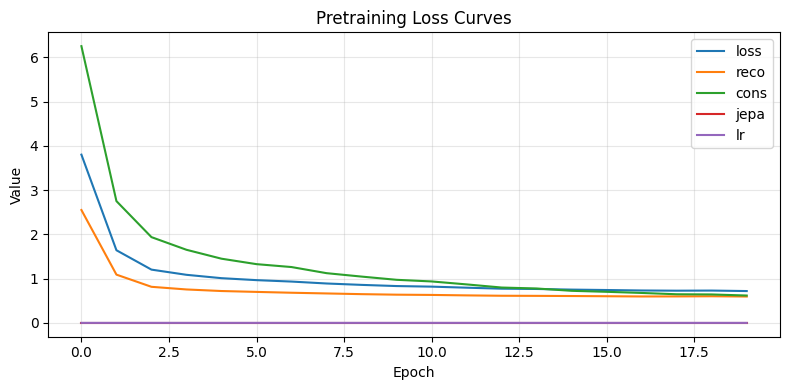

In [22]:
plot_curves(pre_hist, 'Pretraining Loss Curves')


In [23]:
@torch.no_grad()
def show_reco_examples(model, loader, cfg, n_events=2):
    model.eval()
    batch = next(iter(loader)); batch = to_device(batch, device)
    vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
    out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

    names = list(cfg.PER_PARTICLE_FEATURES)
    for b in range(min(n_events, batch['x'].size(0))):
        idx = torch.where(rm[b])[0][:8]
        if len(idx) == 0: continue
        print(f'Event {b}, masked tokens shown: {len(idx)}')
        for fname in ['px','py','pz','E','pt']:
            j = names.index(fname)
            t = tgt[b, idx, j].detach().cpu().numpy()
            p = out['reco'][b, idx, j].detach().cpu().numpy()
            print(f'  {fname} true[:4]={np.round(t[:4],3)} pred[:4]={np.round(p[:4],3)}')

show_reco_examples(model, train_loader, cfg)


Event 0, masked tokens shown: 8
  px true[:4]=[0.916 0.078 0.342 0.123] pred[:4]=[1.058 0.192 0.353 0.171]
  py true[:4]=[-4.361 -2.551 -2.357 -2.084] pred[:4]=[-4.456 -2.674 -2.431 -2.164]
  pz true[:4]=[-2.999 -1.38  -1.261 -0.994] pred[:4]=[-3.165 -1.59  -1.344 -1.15 ]
  E true[:4]=[4.391 2.579 2.388 2.109] pred[:4]=[4.377 2.646 2.419 2.161]
  pt true[:4]=[4.361 2.551 2.358 2.084] pred[:4]=[4.401 2.589 2.365 2.104]
Event 1, masked tokens shown: 8
  px true[:4]=[-3.479 -3.165 -2.576 -2.554] pred[:4]=[-3.475 -3.154 -2.587 -2.558]
  py true[:4]=[ 1.535 -2.112 -1.635 -1.643] pred[:4]=[ 1.532 -2.06  -1.619 -1.618]
  pz true[:4]=[2.745 2.115 1.626 1.58 ] pred[:4]=[2.699 2.113 1.637 1.603]
  E true[:4]=[3.579 3.255 2.671 2.649] pred[:4]=[3.521 3.247 2.665 2.645]
  pt true[:4]=[3.486 3.212 2.627 2.608] pred[:4]=[3.408 3.181 2.622 2.605]


## 12. Fine-Tuning Run
Load pretrained or scratch weights and optimize classification on labeled data.

In [24]:
ckpt_path = Path('./checkpoints/hybrid_mae_pretrained.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_path)

ft_model = HybridLorentzParTMAE(cfg).to(device)
ft_model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)

                                                                      
optf   = make_optimizer(ft_model, cfg, finetune_mode=True)                
schf   = make_scheduler(optf, cfg.FINETUNE_EPOCHS,
                        warmup_epochs=cfg.WARMUP_EPOCHS)                  
scalerf = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
early   = EarlyStopping(patience=cfg.EARLY_STOP_PATIENCE, mode='max')

best_path    = Path('./checkpoints/hybrid_mae_best_finetune.pt')
best_val_auc = -np.inf

ft_hist = {'train_loss': [], 'train_acc': [], 'val_acc': [],
           'val_auc_ovr': [], 'val_auc_ovo': [], 'lr': []}

for ep in range(cfg.FINETUNE_EPOCHS):
    tr = train_epoch_finetune(ft_model, train_loader, optf, scalerf,
                              device, cfg, class_weights=class_weights)
    va, *_ = eval_finetune(ft_model, val_loader, device, cfg)
    current_lr = schf.get_last_lr()[0]
    schf.step()

    val_auc = va['macro_auc_ovr']
    if np.isnan(val_auc):
        val_auc = va['accuracy']

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(ft_model.state_dict(), best_path)

    ft_hist['train_loss'].append(tr['loss'])
    ft_hist['train_acc'].append(tr['acc'])
    ft_hist['val_acc'].append(va['accuracy'])
    ft_hist['val_auc_ovr'].append(va['macro_auc_ovr'])
    ft_hist['val_auc_ovo'].append(va.get('macro_auc_ovo', np.nan))
    ft_hist['lr'].append(current_lr)

    print(f"[Finetune {ep+1:2d}/{cfg.FINETUNE_EPOCHS}]"
          f"  train_loss={tr['loss']:.4f}"
          f"  train_acc={tr['acc']:.4f}"
          f"  val_acc={va['accuracy']:.4f}"
          f"  val_auc={val_auc:.4f}"
          f"  lr={current_lr:.2e}")

    if early.step(val_auc):
        print(f"Early stopping at epoch {ep+1}."
              f" Best val_auc={best_val_auc:.4f}")
        break

if best_path.exists():
    ft_model.load_state_dict(
        torch.load(best_path, map_location=device), strict=False)
    print(f"Loaded best fine-tuned checkpoint (val_auc={best_val_auc:.4f})")


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune  1/35]  train_loss=2.0068  train_acc=0.2821  val_acc=0.4251  val_auc=0.8524  lr=3.00e-05


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune 32/35]  train_loss=1.1130  train_acc=0.7292  val_acc=0.6867  val_auc=0.9490  lr=4.29e-06


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune 33/35]  train_loss=1.1117  train_acc=0.7296  val_acc=0.6926  val_auc=0.9499  lr=2.82e-06
Early stopping at epoch 33. Best val_auc=0.9519
Loaded best fine-tuned checkpoint (val_auc=0.9519)


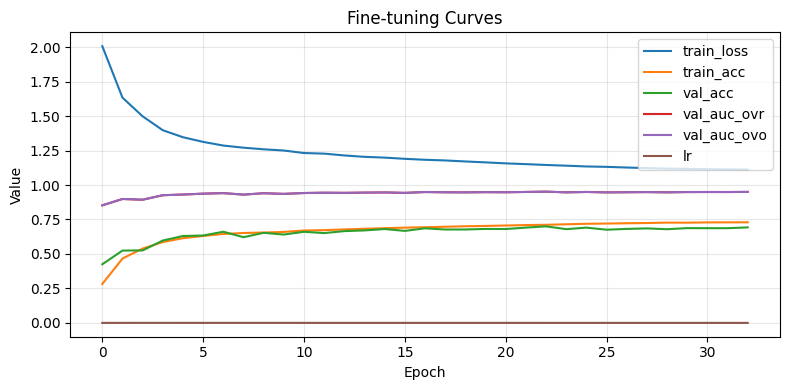

In [25]:
plot_curves(ft_hist, 'Fine-tuning Curves')


Eval:   0%|          | 0/79 [00:00<?, ?it/s]

  Overall accuracy : 0.7018
  Macro AUC (OvR) : 0.9524
  Macro AUC (OvO) : 0.9525

Per-class metrics (ParT-paper Table 1 format):
               AUC      Rej50%      Rej30%   Rej99%  Rej99.5%
class                                                        
HToBB       0.9200        34.2       101.1      1.9       1.6
HToCC       0.9097        33.3       119.9      1.7       1.6
HToGG       0.9411        43.7       120.0      2.5       2.1
HToWW2Q1L   0.9949      3005.0      9015.0     12.0       7.8
HToWW4Q     0.9627        94.7       281.1      2.6       2.2
TTBar       0.9859       219.4       562.2      6.2       4.1
TTBarLep    0.9962 100000000.0 100000000.0     15.0       9.5
WToQQ       0.9488        43.5        98.8      2.5       2.2
ZJetsToNuNu 0.9505       264.5      2248.5      1.9       1.7
ZToQQ       0.9143        23.0        48.4      1.6       1.5

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

       HToBB   

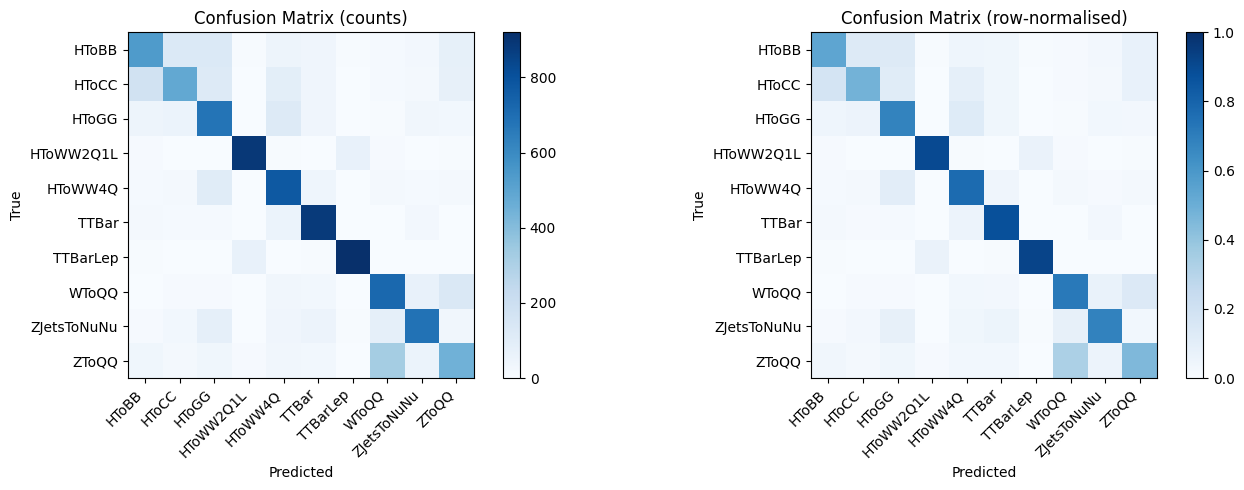

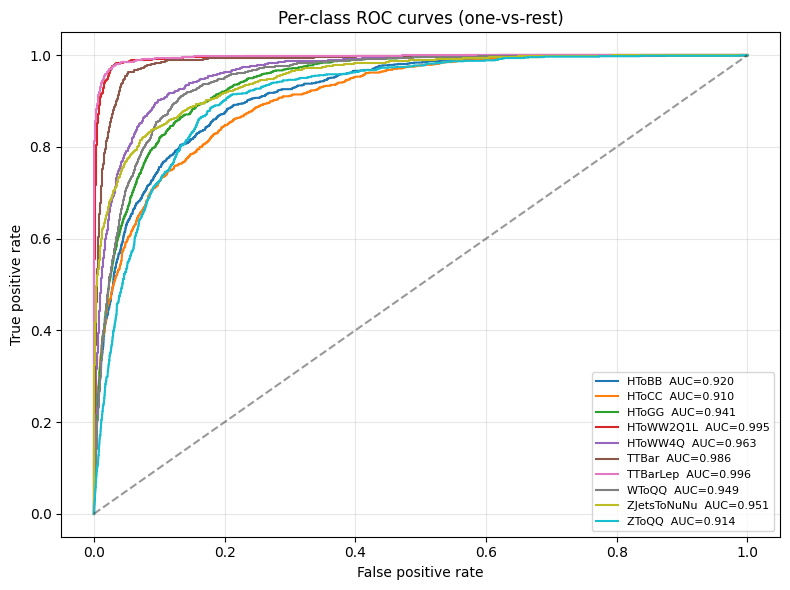


Background rejection at multiple signal efficiencies:
               AUC      Rej50%      Rej30%  Rej99%
class                                             
HToBB       0.9200        34.2       101.1     1.9
HToCC       0.9097        33.3       119.9     1.7
HToGG       0.9411        43.7       120.0     2.5
HToWW2Q1L   0.9949      3005.0      9015.0    12.0
HToWW4Q     0.9627        94.7       281.1     2.6
TTBar       0.9859       219.4       562.2     6.2
TTBarLep    0.9962 100000000.0 100000000.0    15.0
WToQQ       0.9488        43.5        98.8     2.5
ZJetsToNuNu 0.9505       264.5      2248.5     1.9
ZToQQ       0.9143        23.0        48.4     1.6


In [26]:
test_metrics, y_true, y_prob, y_pred = eval_finetune(
    ft_model, test_loader, device, cfg)

                                                                
per_class_df = print_physics_summary(
    test_metrics, y_true, y_prob, class_names, cfg)

print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(y_true, y_pred,
                             target_names=[str(c) for c in class_names],
                             zero_division=0))

plot_confusion(y_true, y_pred, class_names)
plot_rocs(y_true, y_prob, class_names)

                                      
print("\nBackground rejection at multiple signal efficiencies:")
print(per_class_df[["AUC","Rej50%","Rej30%","Rej99%"]].to_string(
    float_format=lambda x: f"{x:.1f}" if x > 1 else f"{x:.4f}"))


## 13. Ablation Study
We compare architecture variants and quantify pretraining impact.

In [27]:

def ablation_config(base: Config, name: str) -> Config:
    c = copy.deepcopy(base)
    if name == 'part_only':
        c.NUM_LAYERS_LORENTZ = 0
    elif name == 'lorentz_only':
        c.NUM_LAYERS_PART = 0
    elif name == 'naive_concat':
        c.USE_TOKEN_GATE = False; c.USE_EVENT_GATE = False
    elif name == 'gated_fusion':
        c.USE_TOKEN_GATE = True; c.USE_EVENT_GATE = True
    elif name == 'no_mass_aux':
        c.USE_AUX_MASS = False
    elif name == 'with_mass_aux':
        c.USE_AUX_MASS = True
    elif name in ['with_mae_pretrain','no_mae_pretrain']:
        pass
    else:
        raise ValueError(name)
    return c

def run_quick_ablations(cfg, train_loader, val_loader, names):
    rows = []
    for name in names:
        c = ablation_config(cfg, name)
        m = HybridLorentzParTMAE(c).to(device)
        o = make_optimizer(m, c)
        s = make_scheduler(o, 1, warmup_epochs=0)
        g = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        tr = train_epoch_finetune(m, train_loader, o, g, device, c, class_weights=class_weights)
        va, *_ = eval_finetune(m, val_loader, device, c)
        s.step()

        row = {'ablation': name, 'train_loss': tr['loss'], 'train_acc': tr['acc'], 'val_acc': va['accuracy'], 'val_auc': va['macro_auc_ovr']}
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_model_quick(model, loader, cfg):
    met, *_ = eval_finetune(model, loader, device, cfg)
    return {'val_acc': met['accuracy'], 'val_auc': met['macro_auc_ovr']}

def run_pretrain_vs_scratch_ablation(base_cfg, train_loader, val_loader, class_weights):
    c = copy.deepcopy(base_cfg)
    c.PRETRAIN_EPOCHS = 2
    c.FINETUNE_EPOCHS = 3

    feat_idx = {k:i for i,k in enumerate(c.PER_PARTICLE_FEATURES)}

    pretrained = HybridLorentzParTMAE(c).to(device)
    optp = make_optimizer(pretrained, c)
    scp = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shp = make_scheduler(optp, c.PRETRAIN_EPOCHS)
    for ep in range(c.PRETRAIN_EPOCHS):
        logs = train_epoch_pretrain(pretrained, train_loader, optp, scp, device, c, feat_idx)
        shp.step()
        print(f"[Ablation-Pretrain {ep+1}/{c.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f}")

    optf_p = make_optimizer(pretrained, c)
    scf_p = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_p = make_scheduler(optf_p, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(pretrained, train_loader, optf_p, scf_p, device, c, class_weights=class_weights)
        shf_p.step()
        print(f"[Ablation-Finetune Pretrained {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_pre = evaluate_model_quick(pretrained, val_loader, c)

    scratch = HybridLorentzParTMAE(c).to(device)
    optf_s = make_optimizer(scratch, c)
    scf_s = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_s = make_scheduler(optf_s, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(scratch, train_loader, optf_s, scf_s, device, c, class_weights=class_weights)
        shf_s.step()
        print(f"[Ablation-Finetune Scratch {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_scr = evaluate_model_quick(scratch, val_loader, c)

    rows = [
        {'ablation': 'with_mae_pretrain', 'val_acc': m_pre['val_acc'], 'val_auc': m_pre['val_auc']},
        {'ablation': 'no_mae_pretrain', 'val_acc': m_scr['val_acc'], 'val_auc': m_scr['val_auc']},
    ]
    return pd.DataFrame(rows)

ablation_names = ['part_only','lorentz_only','naive_concat','gated_fusion','no_mass_aux','with_mass_aux']
ablation_df = run_quick_ablations(cfg, train_loader, val_loader, ablation_names)
mae_ablation_df = run_pretrain_vs_scratch_ablation(cfg, train_loader, val_loader, class_weights)
ablation_all_df = pd.concat([ablation_df, mae_ablation_df], ignore_index=True)
ablation_all_df


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

{'ablation': 'part_only', 'train_loss': 2.1281473861694336, 'train_acc': 0.201325, 'val_acc': 0.3379, 'val_auc': 0.801180639790657}


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

[Ablation-Finetune Scratch 2/3] loss=1.5778 acc=0.4924


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

[Ablation-Finetune Scratch 3/3] loss=1.3880 acc=0.5927


Eval:   0%|          | 0/79 [00:00<?, ?it/s]

,ablation,train_loss,train_acc,val_acc,val_auc
0,part_only,2.128147,0.201325,0.3379,0.801181
1,lorentz_only,2.028432,0.241012,0.3408,0.823851
2,naive_concat,2.073535,0.215537,0.4233,0.853555
3,gated_fusion,1.995237,0.259950,0.5175,0.889243
4,no_mass_aux,1.990883,0.251437,0.4063,0.862459
5,with_mass_aux,2.004476,0.287062,0.5262,0.895241
6,with_mae_pretrain,NaN,NaN,0.5084,0.892281
7,no_mae_pretrain,NaN,NaN,0.5564,0.909818


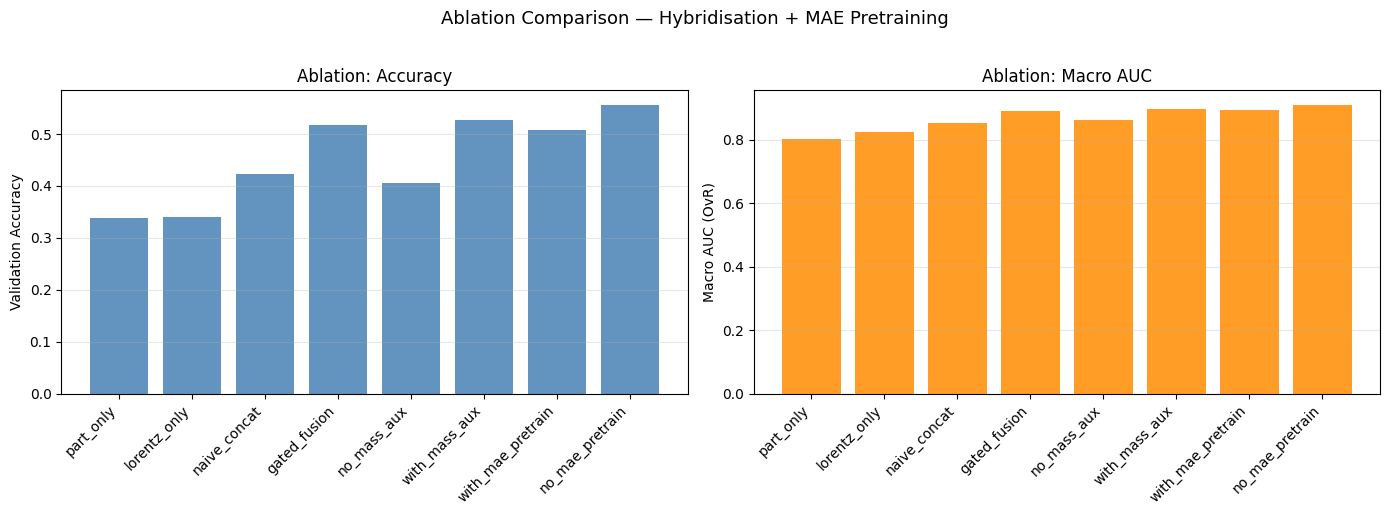

         ablation  train_loss  train_acc  val_acc  val_auc
        part_only    2.128147   0.201325   0.3379 0.801181
     lorentz_only    2.028432   0.241012   0.3408 0.823851
     naive_concat    2.073535   0.215537   0.4233 0.853555
     gated_fusion    1.995237   0.259950   0.5175 0.889243
      no_mass_aux    1.990883   0.251437   0.4063 0.862459
    with_mass_aux    2.004476   0.287062   0.5262 0.895241
with_mae_pretrain         NaN        NaN   0.5084 0.892281
  no_mae_pretrain         NaN        NaN   0.5564 0.909818


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                    
axes[0].bar(ablation_all_df['ablation'], ablation_all_df['val_acc'],
            color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(ablation_all_df)))
axes[0].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Ablation: Accuracy')
axes[0].grid(axis='y', alpha=0.3)

               
axes[1].bar(ablation_all_df['ablation'],
            ablation_all_df['val_auc'].fillna(0),
            color='darkorange', alpha=0.85)
axes[1].set_xticks(range(len(ablation_all_df)))
axes[1].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[1].set_ylabel('Macro AUC (OvR)')
axes[1].set_title('Ablation: Macro AUC')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ablation Comparison — Hybridisation + MAE Pretraining',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(ablation_all_df.to_string(index=False))


### Multi-seed Evaluation
Results are repeated across multiple seeds to report mean performance and variability.

In [29]:
def run_multiseed_eval(base_cfg: Config, train_loader, val_loader, test_loader,
                       class_weights, n_seeds: int = 3,
                       pretrained_state: Optional[dict] = None) -> pd.DataFrame:
    rows = []
    for seed in range(42, 42 + n_seeds):
        seed_everything(seed)
        c = copy.deepcopy(base_cfg)
        c.SEED = seed
        c.FINETUNE_EPOCHS = min(c.FINETUNE_EPOCHS, 10)                   

        m = HybridLorentzParTMAE(c).to(device)
        if pretrained_state is not None:
            m.load_state_dict(pretrained_state, strict=False)

        opt_s = make_optimizer(m, c, finetune_mode=(pretrained_state is not None))
        sch_s = make_scheduler(opt_s, c.FINETUNE_EPOCHS, c.WARMUP_EPOCHS)
        sc_s  = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        best_auc, best_state = -np.inf, None
        for ep in range(c.FINETUNE_EPOCHS):
            train_epoch_finetune(m, train_loader, opt_s, sc_s, device, c,
                                 class_weights=class_weights)
            va, *_ = eval_finetune(m, val_loader, device, c)
            sch_s.step()
            auc_v = va['macro_auc_ovr'] if not np.isnan(va['macro_auc_ovr']) else va['accuracy']
            if auc_v > best_auc:
                best_auc = auc_v
                best_state = copy.deepcopy(m.state_dict())

        if best_state is not None:
            m.load_state_dict(best_state)
        te, *_ = eval_finetune(m, test_loader, device, c)
        rows.append({
            'seed': seed,
            'test_acc': te['accuracy'],
            'test_auc_ovr': te['macro_auc_ovr'],
        })
        print(f"  seed={seed}  acc={te['accuracy']:.4f}"
              f"  auc={te['macro_auc_ovr']:.4f}")

    df = pd.DataFrame(rows)
    return df


def summarise_seeds(df: pd.DataFrame, label: str):
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    for col in ['test_acc', 'test_auc_ovr']:
        if col in df.columns:
            print(f"  {col}: {df[col].mean():.4f} ± {df[col].std():.4f}")
    print(f"{'='*50}")


N_SEEDS = 3                                                 

print("Running multi-seed: pretrained weights...")
pretrained_weights = torch.load(best_path, map_location='cpu') if best_path.exists() else None
df_pretrained = run_multiseed_eval(
    cfg, train_loader, val_loader, test_loader,
    class_weights, n_seeds=N_SEEDS,
    pretrained_state=pretrained_weights)

print("\nRunning multi-seed: from scratch...")
df_scratch = run_multiseed_eval(
    cfg, train_loader, val_loader, test_loader,
    class_weights, n_seeds=N_SEEDS,
    pretrained_state=None)

summarise_seeds(df_pretrained, "Pretrained (MAE → finetune)")
summarise_seeds(df_scratch,    "From scratch")

comparison_df = pd.DataFrame({
    'mode':    ['pretrained', 'scratch'],
    'acc_mean': [df_pretrained['test_acc'].mean(),  df_scratch['test_acc'].mean()],
    'acc_std':  [df_pretrained['test_acc'].std(),   df_scratch['test_acc'].std()],
    'auc_mean': [df_pretrained['test_auc_ovr'].mean(), df_scratch['test_auc_ovr'].mean()],
    'auc_std':  [df_pretrained['test_auc_ovr'].std(),  df_scratch['test_auc_ovr'].std()],
})
print("\nSummary comparison:")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Running multi-seed: pretrained weights...


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

  seed=44  acc=0.6743  auc=0.9460

  Pretrained (MAE → finetune)
  test_acc: 0.6970 ± 0.0051
  test_auc_ovr: 0.9512 ± 0.0013

  From scratch
  test_acc: 0.6799 ± 0.0049
  test_auc_ovr: 0.9472 ± 0.0012

Summary comparison:
      mode  acc_mean  acc_std  auc_mean  auc_std
pretrained    0.6970   0.0051    0.9512   0.0013
   scratch    0.6799   0.0049    0.9472   0.0012


## 14. Mass Regression
This optional head predicts jet mass jointly with class labels for multi-task learning.

Event gate summary:
 count    384.000000
mean       0.530985
std        0.219455
min        0.042684
25%        0.396365
50%        0.469659
75%        0.647197
max        0.972876
dtype: float64
Token gate summary:
 count    384.000000
mean       0.377948
std        0.039069
min        0.286669
25%        0.346793
50%        0.376527
75%        0.407573
max        0.471017
dtype: float64


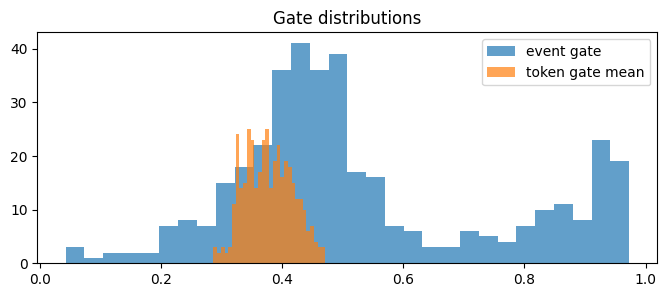

Mean gate by class:
   event_gate  token_gate
y                        
0    0.459428    0.368112
1    0.435746    0.379176
2    0.470384    0.338635
3    0.821177    0.405509
4    0.480382    0.347245
5    0.478664    0.363731
6    0.901816    0.413576
7    0.368406    0.390174
8    0.350400    0.364668
9    0.378681    0.386123


In [30]:
@torch.no_grad()
def inspect_gates(model, loader, n_batches=3):
    model.eval()
    ge, gt, yy = [], [], []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='finetune')
        ge.append(out['g_evt'].squeeze(-1).cpu().numpy())
        gt.append(out['g_tok'].mean(dim=(1,2)).cpu().numpy())
        yy.append(batch['y'].cpu().numpy())

    ge = np.concatenate(ge); gt = np.concatenate(gt); yy = np.concatenate(yy)
    print('Event gate summary:\n', pd.Series(ge).describe())
    print('Token gate summary:\n', pd.Series(gt).describe())

    plt.figure(figsize=(8,3))
    plt.hist(ge, bins=30, alpha=0.7, label='event gate')
    plt.hist(gt, bins=30, alpha=0.7, label='token gate mean')
    plt.legend(); plt.title('Gate distributions'); plt.show()

    df = pd.DataFrame({'y': yy, 'event_gate': ge, 'token_gate': gt})
    print('Mean gate by class:')
    print(df.groupby('y')[['event_gate','token_gate']].mean())

inspect_gates(ft_model, test_loader)


count    4.673000e+03
mean     1.802968e-04
std      2.702352e-04
min      4.677437e-07
25%      2.419512e-05
50%      8.659640e-05
75%      2.340976e-04
max      5.306446e-03
dtype: float64


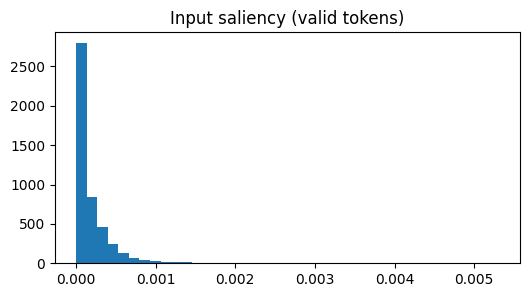

In [31]:
def simple_saliency(model, batch):
    model.eval()
    x = batch['x'].to(device).clone().detach().requires_grad_(True)
    p4, mask, y = batch['p4'].to(device), batch['mask'].to(device), batch['y'].to(device)

    out = model(x, p4, mask, mode='finetune')
    loss = F.cross_entropy(out['logits'], y)
    loss.backward()

    sal = x.grad.abs().mean(dim=-1).detach().cpu().numpy()
    vm = batch['mask'].numpy() > 0.5
    vals = sal[vm]
    print(pd.Series(vals).describe())
    plt.figure(figsize=(6,3)); plt.hist(vals, bins=40)
    plt.title('Input saliency (valid tokens)'); plt.show()

batch0 = next(iter(test_loader))
simple_saliency(ft_model, batch0)


In [33]:
@torch.no_grad()
def reconstruction_failure_cases(model, loader, cfg, topk=5):
    model.eval()
    errs = []
    for batch in loader:
        batch = to_device(batch, device)
        vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
        out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

        reco_dim = out['reco'].shape[-1]
        tgt_reco = tgt[..., :reco_dim]                           

        per_evt = (((out['reco'] - tgt_reco) ** 2).mean(dim=-1) * rm.float()).sum(dim=1)
        errs.extend(per_evt.cpu().numpy().tolist())

    errs = np.array(errs)
    idx = np.argsort(-errs)[:topk]
    print('Top failure indices:', idx)
    print('Errors:', errs[idx])

reconstruction_failure_cases(ft_model, test_loader, cfg)

Top failure indices: [5736 5836 9263 7717 8388]
Errors: [719.60028076 388.86489868 365.89324951 344.66906738 294.33319092]


## 15. Final Results
This section summarizes the main quantitative outcomes and key takeaways.

In [34]:
                                                                             
try:
    _cfg_ready   = isinstance(cfg, Config)
    _model_ready = 'ft_model' in dir() and ft_model is not None
except NameError:
    _cfg_ready = _model_ready = False

if not _cfg_ready:
    print("[INFO] Run all cells from the top first (cfg not defined yet).")
elif not _model_ready:
    print("[INFO] Run the fine-tuning section first (ft_model not defined yet).")
elif not cfg.USE_AUX_MASS:
    print("[INFO] Mass regression is disabled.")
    print("       Set  cfg.USE_AUX_MASS = True  before the pretraining run")
    print("       and re-run from Section 11 to activate it.")
else:
                                                                              
    test_metrics_mass, _yt, _yp_prob, _yp = eval_finetune(
        ft_model, test_loader, device, cfg)

    ft_model.eval()
    true_m, pred_m = [], []
    with torch.no_grad():
        for _batch in test_loader:
            _batch = to_device(_batch, device)
            _out   = ft_model(_batch['x'], _batch['p4'], _batch['mask'],
                               mode='multitask')
            true_m.extend(_batch['mass'].cpu().numpy().tolist())
            if 'mass_pred' in _out:
                pred_m.extend(_out['mass_pred'].cpu().numpy().tolist())

    if not pred_m:
        print("[WARN] No mass predictions found. "
              "Ensure USE_AUX_MASS=True was set before training.")
    else:
        true_m = np.array(true_m, dtype=np.float32)
        pred_m = np.array(pred_m, dtype=np.float32)

                                                                                         
        if getattr(cfg, 'MASS_TARGET_NORMALIZE', False):
            mass_mean = float(getattr(cfg, 'MASS_MEAN', 0.0))
            mass_std = float(getattr(cfg, 'MASS_STD', 1.0))
            true_m = true_m * mass_std + mass_mean
            pred_m = pred_m * mass_std + mass_mean

                                                                             
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].scatter(true_m, pred_m, s=2, alpha=0.25, c='steelblue')
        _lim = [min(true_m.min(), pred_m.min()),
                max(true_m.max(), pred_m.max())]
        axes[0].plot(_lim, _lim, 'r--', lw=1.2, label='ideal')
        axes[0].set_xlabel('True mass [GeV]')
        axes[0].set_ylabel('Predicted mass [GeV]')
        mae_v  = test_metrics_mass.get('mass_mae',  float('nan'))
        rmse_v = test_metrics_mass.get('mass_rmse', float('nan'))
        axes[0].set_title(f"Mass regression  MAE={mae_v:.3f} GeV")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

                                                                              
        residual = pred_m - true_m
        axes[1].hist(residual, bins=60, density=True,
                     color='darkorange', alpha=0.8)
        axes[1].axvline(0, color='r', lw=1.2, ls='--')
        axes[1].set_xlabel('Residual  (pred − true) [GeV]')
        axes[1].set_title(f"Residual  μ={residual.mean():.2f}"
                          f"  σ={residual.std():.2f}")
        axes[1].grid(alpha=0.3)

                                                                              
        eps      = 1e-3
        rel_err  = np.abs(residual) / (true_m + eps)
        axes[2].scatter(true_m, rel_err, s=2, alpha=0.2, c='seagreen')
        axes[2].set_xlabel('True mass [GeV]')
        axes[2].set_ylabel('|pred − true| / true')
        axes[2].set_title('Relative error vs true mass')
        axes[2].set_ylim(0, min(np.percentile(rel_err, 99), 2.0))
        axes[2].grid(alpha=0.3)

        plt.suptitle('Mass Regression Evaluation', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

        print(f"Mass MAE  : {mae_v:.4f} GeV")
        print(f"Mass RMSE : {rmse_v:.4f} GeV")
        print(f"Residual  : mean={residual.mean():.4f}  std={residual.std():.4f}")

[INFO] Mass regression is disabled.
       Set  cfg.USE_AUX_MASS = True  before the pretraining run
       and re-run from Section 11 to activate it.


In [35]:
print(json.dumps(asdict(cfg), indent=2))

{
  "DATA_ROOT": "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26 p-3\\datasets\\JetClass",
  "MAX_PARTICLES": 50,
  "NUM_CLASSES": 10,
  "BATCH_SIZE": 128,
  "NUM_WORKERS": 0,
  "PRETRAIN_EPOCHS": 20,
  "FINETUNE_EPOCHS": 35,
  "LEARNING_RATE": 0.0003,
  "WEIGHT_DECAY": 0.01,
  "MASK_RATIO": 0.4,
  "USE_PATCH_MASKING": true,
  "PATCH_GRID_SIZE": 4,
  "PATCH_ETA_RANGE": 0.5,
  "PATCH_PHI_RANGE": 0.5,
  "PATCH_MASK_FRAC": 0.4,
  "USE_MASK_TOKEN": true,
  "USE_PID_PRETRAIN_HEAD": true,
  "PID_HEAD_WEIGHT": 0.5,
  "WARMUP_EPOCHS": 3,
  "LABEL_SMOOTHING": 0.1,
  "USE_BIASED_MASK": true,
  "BACKBONE_LR_FACTOR": 0.3,
  "KINEMATIC_LOG_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    "pt",
    "deltaR"
  ],
  "MASS_TARGET_NORMALIZE": true,
  "MASS_NORM_EPS": 1e-06,
  "GATE_REG_WEIGHT": 0.02,
  "USE_JEPA_PRETRAIN": false,
  "JEPA_WEIGHT": 0.5,
  "JEPA_EMA_DECAY": 0.996,
  "ATTN_INTERACTION_GATE_STRENGTH": 1.0,
  "USE_PHYSICS_RECO_WEIGHTING": true,
  "RECO_WEIGHT_PT": 1.0,
  "RECO_WEIGHT_ETA": 0.5,

## 16. Notes
The workflow is organized for clarity: setup, data, features, model, training, evaluation, and analysis.
Use this notebook as the primary experiment log for the hybrid JetClass pipeline.